# Interpretable Recidivism Classification and Fairness Evaluation

## Project Overview

This project evaluates interpretable classification models for predicting recidivism outcomes using the COMPAS recidivism dataset. The analysis includes exploratory data analysis, leakage-free model development, comparison of Logistic Regression and Random Forest models against a baseline classifier, held-out test evaluation, coefficient interpretation, and error-rate analysis.

Since recidivism prediction is a sensitive application area, model performance must be considered alongside fairness, interpretability, and the consequences of classification errors.

## Research Question

Can an interpretable classification model estimate recidivism outcomes from age, criminal-history, and case-related variables, and do the model's classification errors vary across demographic groups?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 26

FIGURE_DIR = Path("images")
OUTPUT_DIR = Path("outputs")

FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

# Load dataset
dataset = load_dataset("imodels/compas-recidivism")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

df_train.head()

Training set shape: (4937, 21)
Test set shape: (1235, 21)


,age,priors_count,days_b_screening_arrest,c_jail_time,juv_fel_count,juv_other_count,juv_misd_count,c_charge_degree:F,c_charge_degree:M,race:African-American,race:Asian,race:Caucasian,race:Hispanic,race:Native_American,race:Other,age_cat:25_-_45,age_cat:Greater_than_45,age_cat:Less_than_25,sex:Female,sex:Male,is_recid
0,40.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,25.0,1.0,-1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1
2,36.0,11.0,-1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,23.0,1.0,-1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
4,29.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0


## Data Description and Feature Selection

The dataset contains a binary recidivism outcome together with numerical, charge-related, and demographic indicator variables.

### Variables Used for Model Training

The model uses the following numerical and case-related predictors:
- age (Age of the individual)
- priors_count (Number of prior offenses)
- days_b_screening_arrest (Days between screening and arrest)
- c_jail_time (Total time spent in jail)
- juv_fel_count (Juvenile felony count)
- juv_misd_count (Juvenile misdemeanor count)
- juv_other_count (Other juvenile offenses)

These variables were selected to preserve the original project's focus on interpretable predictors while retaining charge degree as a potentially relevant case-related indicator.

### Variables Retained for Fairness Evaluation Only

The following variables are excluded from model training and retained only to compare model error rates across groups:

- Race indicator variables.
- Sex indicator variables.

Excluding these variables from training does not by itself guarantee fairness. A model can still produce unequal error rates because other variables may reflect historical or structural differences. For this reason, subgroup evaluation is included later in the analysis.


## Data Preparation

The following preparation steps were used:

- Checked required model fields for missing values.
- Defined model predictors separately from demographic fields used for fairness auditing.
- Used the dataset's provided training and test splits.
- Created a validation split only from the training data for model comparison.
- Standardized numerical predictors inside a Scikit-learn pipeline for Logistic Regression.

Using a pipeline is important because the scaler is fitted only on the training data. This prevents information from the validation or held-out test data from influencing model training.

In [2]:
TARGET = "is_recid"

NUMERIC_FEATURES = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "c_jail_time",
    "juv_fel_count",
    "juv_other_count",
    "juv_misd_count"
]

CASE_FEATURES = ["c_charge_degree:F"]

MODEL_FEATURES = NUMERIC_FEATURES + CASE_FEATURES

RACE_COLUMNS = [
    column for column in df_train.columns
    if column.startswith("race:")
]

SEX_COLUMNS = [
    column for column in df_train.columns
    if column.startswith("sex:")
]

required_columns = MODEL_FEATURES + [TARGET]
missing_columns = [
    column for column in required_columns
    if column not in df_train.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Model features:")
print(MODEL_FEATURES)

print("\nRace columns retained for fairness evaluation:")
print(RACE_COLUMNS)

print("\nSex columns retained for fairness evaluation:")
print(SEX_COLUMNS)

print("\nMissing values in training model fields:")
print(df_train[required_columns].isnull().sum())

print("\nMissing values in test model fields:")
print(df_test[required_columns].isnull().sum())

print("\nTraining target distribution:")
target_distribution = (
    df_train[TARGET]
    .value_counts()
    .rename(index={0: "No Recidivism", 1: "Recidivism"})
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"] / target_distribution["Count"].sum() * 100
).round(2)

target_distribution

Model features:
['age', 'priors_count', 'days_b_screening_arrest', 'c_jail_time', 'juv_fel_count', 'juv_other_count', 'juv_misd_count', 'c_charge_degree:F']

Race columns retained for fairness evaluation:
['race:African-American', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Native_American', 'race:Other']

Sex columns retained for fairness evaluation:
['sex:Female', 'sex:Male']

Missing values in training model fields:
age                        0
priors_count               0
days_b_screening_arrest    0
c_jail_time                0
juv_fel_count              0
juv_other_count            0
juv_misd_count             0
c_charge_degree:F          0
is_recid                   0
dtype: int64

Missing values in test model fields:
age                        0
priors_count               0
days_b_screening_arrest    0
c_jail_time                0
juv_fel_count              0
juv_other_count            0
juv_misd_count             0
c_charge_degree:F          0
is_recid              

,Count,Percentage
No Recidivism,2532,51.29
Recidivism,2405,48.71


In [3]:
X_train_full = df_train[MODEL_FEATURES].copy()
y_train_full = df_train[TARGET].astype(int).copy()

X_test_final = df_test[MODEL_FEATURES].copy()
y_test_final = df_test[TARGET].astype(int).copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Development training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Final held-out test set:", X_test_final.shape)

Development training set: (3949, 8)
Validation set: (988, 8)
Final held-out test set: (1235, 8)


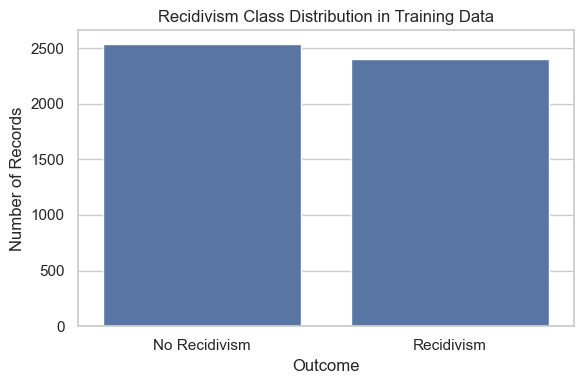

,Count,Percentage
No Recidivism,2532,51.29
Recidivism,2405,48.71


In [4]:
plt.figure(figsize=(6, 4))

axis = sns.countplot(
    data=df_train,
    x=TARGET
)

axis.set_title("Recidivism Class Distribution in Training Data")
axis.set_xlabel("Outcome")
axis.set_ylabel("Number of Records")
axis.set_xticklabels(["No Recidivism", "Recidivism"])

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

target_distribution

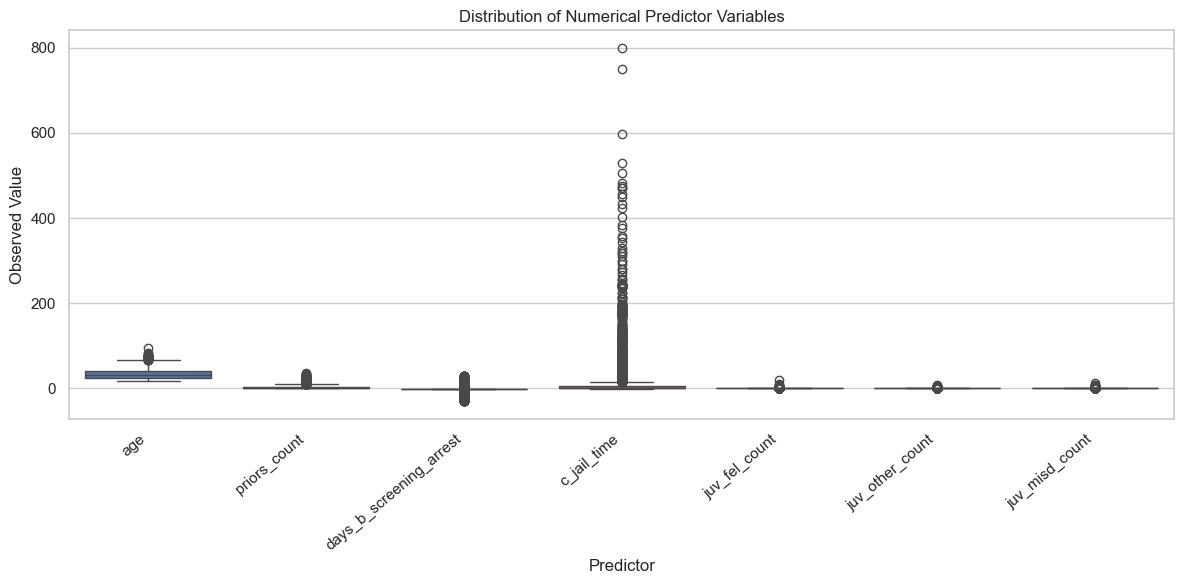

In [5]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_train[NUMERIC_FEATURES]
)

plt.title("Distribution of Numerical Predictor Variables")
plt.xlabel("Predictor")
plt.ylabel("Observed Value")
plt.xticks(rotation=40, ha="right")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "numerical_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

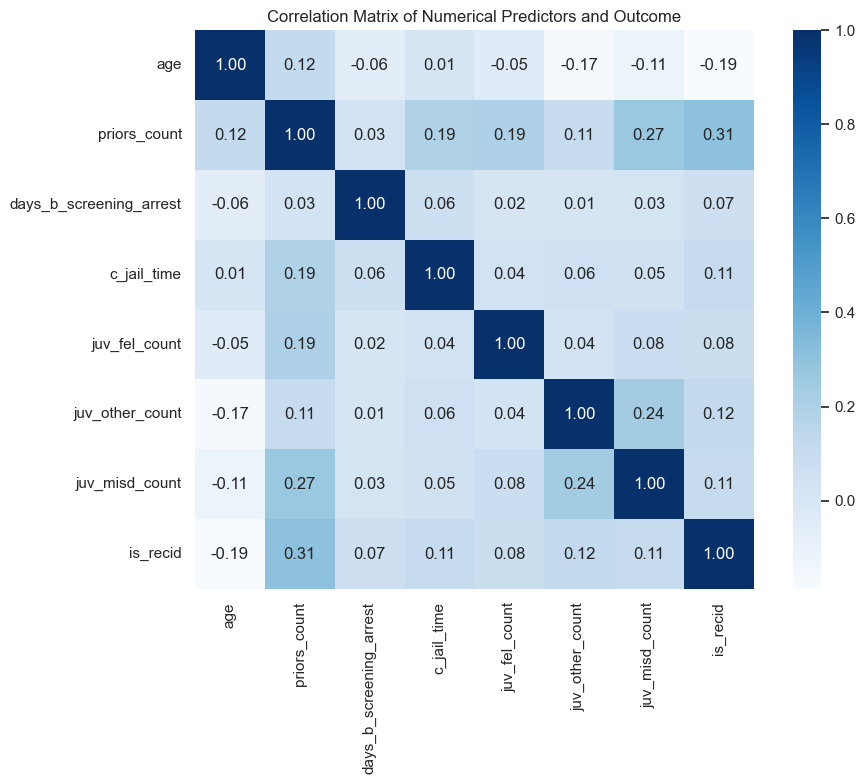

is_recid                   1.000000
priors_count               0.305032
juv_other_count            0.120417
c_jail_time                0.109909
juv_misd_count             0.105917
juv_fel_count              0.081618
days_b_screening_arrest    0.070125
age                       -0.187920
Name: is_recid, dtype: float64

In [6]:
correlation_columns = NUMERIC_FEATURES + [TARGET]
correlation_matrix = df_train[correlation_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)

plt.title("Correlation Matrix of Numerical Predictors and Outcome")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

correlation_matrix[TARGET].sort_values(ascending=False)

## Model Development and Comparison

Three models were evaluated:

1. **Dummy Classifier:** establishes a simple majority-class baseline.
2. **Logistic Regression:** provides an interpretable linear classification model.
3. **Random Forest:** provides a non-linear comparison model capable of capturing more complex relationships.

Logistic Regression uses a preprocessing pipeline that standardizes numerical features using only training data. Models are compared on a validation split using accuracy, precision, recall, F1-score, and ROC-AUC. The best-performing candidate model by validation ROC-AUC is then refitted using the full training dataset and evaluated once on the untouched held-out test dataset.

In [7]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), NUMERIC_FEATURES)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    ),

    "Logistic Regression": Pipeline([
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

models

{'Dummy Baseline': DummyClassifier(random_state=26, strategy='most_frequent'),
 'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('numeric', StandardScaler(),
                                                   ['age', 'priors_count',
                                                    'days_b_screening_arrest',
                                                    'c_jail_time',
                                                    'juv_fel_count',
                                                    'juv_other_count',
                                                    'juv_misd_count'])],
                                    verbose_feature_names_out=False)),
                 ('model', LogisticRegression(max_iter=1000, random_state=26))]),
 'Random Forest': RandomForestClassifier(min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                        random_state=26)}

In [8]:
def evaluate_classifier(model, X, y, model_name):
    """
    Evaluate a fitted binary classifier using common classification metrics.
    """
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_probability = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y, y_probability)
    else:
        y_probability = None
        roc_auc = np.nan

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc
    }

    return results, y_pred, y_probability

In [9]:
validation_results = []
validation_models = {}

for model_name, model in models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    results, _, _ = evaluate_classifier(
        fitted_model,
        X_val,
        y_val,
        model_name
    )

    validation_results.append(results)
    validation_models[model_name] = fitted_model

validation_results_df = (
    pd.DataFrame(validation_results)
    .set_index("Model")
    .sort_values("ROC-AUC", ascending=False)
    .round(3)
)

validation_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.689,0.704,0.624,0.662,0.741
Random Forest,0.654,0.648,0.634,0.641,0.718
Dummy Baseline,0.513,0.000,0.000,0.000,0.500


Logistic Regression achieved the highest validation ROC-AUC of 0.741, compared with 0.718 for Random Forest and 0.500 for the dummy baseline. It was therefore selected for final held-out evaluation.

## Validation Performance

The validation set is used to compare candidate models before final evaluation. Accuracy is reported, but it is not used alone because classification errors may have different consequences in this setting. Precision, recall, F1-score, and ROC-AUC provide a more complete picture of model performance.

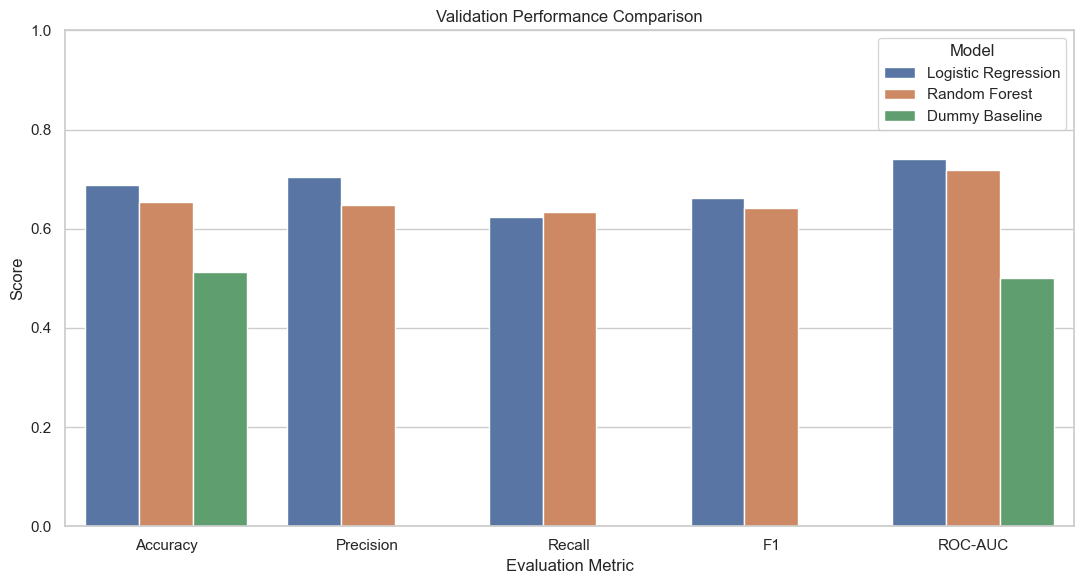

In [10]:
comparison_plot_data = (
    validation_results_df
    .reset_index()
    .melt(
        id_vars="Model",
        value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Validation Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="upper right")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "validation_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
candidate_results = validation_results_df.drop(index="Dummy Baseline")

selected_model_name = candidate_results["ROC-AUC"].idxmax()

print("Selected model based on validation ROC-AUC:")
print(selected_model_name)

Selected model based on validation ROC-AUC:
Logistic Regression


In [12]:
final_model = clone(models[selected_model_name])

final_model.fit(X_train_full, y_train_full)

final_results, y_pred_final, y_probability_final = evaluate_classifier(
    final_model,
    X_test_final,
    y_test_final,
    selected_model_name
)

final_results_df = (
    pd.DataFrame([final_results])
    .set_index("Model")
    .round(3)
)

print("Final held-out test performance:")
display(final_results_df)

print("\nClassification Report:")
print(
    classification_report(
        y_test_final,
        y_pred_final,
        target_names=["No Recidivism", "Recidivism"],
        zero_division=0
    )
)

Final held-out test performance:


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.675,0.671,0.617,0.643,0.726



Classification Report:
               precision    recall  f1-score   support

No Recidivism       0.68      0.73      0.70       650
   Recidivism       0.67      0.62      0.64       585

     accuracy                           0.68      1235
    macro avg       0.67      0.67      0.67      1235
 weighted avg       0.68      0.68      0.67      1235



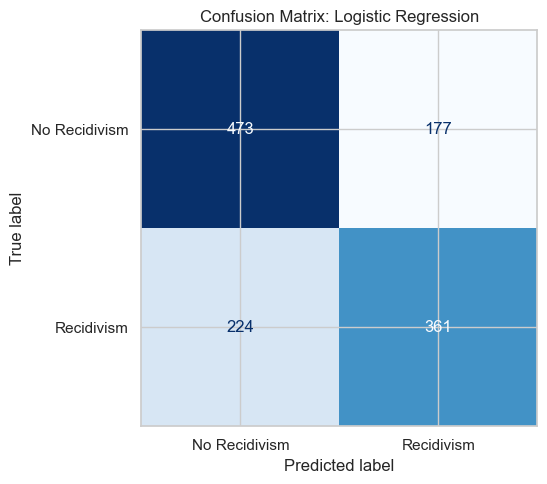

In [13]:
confusion = confusion_matrix(y_test_final, y_pred_final)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["No Recidivism", "Recidivism"]
)

figure, axis = plt.subplots(figsize=(6, 5))

display_matrix.plot(
    ax=axis,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

axis.set_title(f"Confusion Matrix: {selected_model_name}")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Model Interpretability

Logistic Regression is examined separately for interpretability, regardless of which candidate model performs best on validation data. Because the numerical predictors are standardized inside the Logistic Regression pipeline, coefficient magnitude can be used to compare the relative direction and strength of associations within this model.

Coefficients should be interpreted as model associations rather than causal relationships.

In [14]:
interpretable_model = clone(models["Logistic Regression"])
interpretable_model.fit(X_train_full, y_train_full)

feature_names = (
    interpretable_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    interpretable_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute Coefficient": np.abs(coefficients)
    })
    .sort_values("Absolute Coefficient", ascending=False)
)

coefficient_table[["Feature", "Coefficient"]].round(3)

,Feature,Coefficient
1,priors_count,0.855
0,age,-0.501
7,c_charge_degree:F,0.220
5,juv_other_count,0.129
3,c_jail_time,0.119
2,days_b_screening_arrest,0.115
4,juv_fel_count,0.044
6,juv_misd_count,-0.030


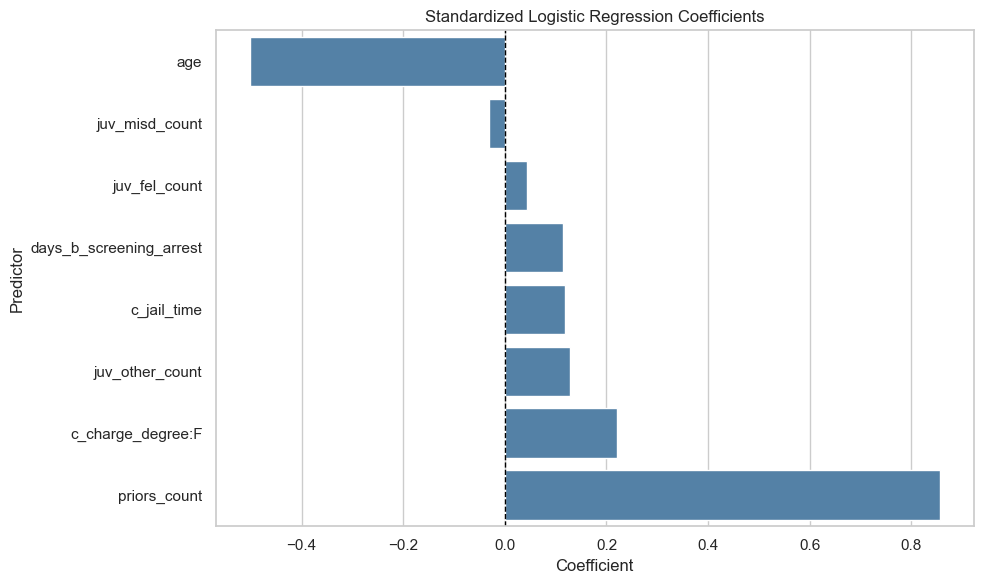

In [15]:
coefficient_plot_data = (
    coefficient_table
    .sort_values("Coefficient", ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficient_plot_data,
    x="Coefficient",
    y="Feature",
    color="steelblue"
)

plt.axvline(0, linestyle="--", linewidth=1, color="black")
plt.title("Standardized Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Subgroup Fairness Evaluation

Race and sex variables were excluded from model training and are used here only to evaluate whether classification errors vary across demographic groups.

The analysis focuses on:

- Accuracy by subgroup.
- Recall by subgroup.
- False positive rate by subgroup.
- False negative rate by subgroup.
- Predicted positive rate by subgroup.

This analysis does not establish whether a model is fair or appropriate for real-world use. It is a diagnostic step intended to identify potential differences in model behaviour across groups.

In [16]:
def reconstruct_group_from_indicators(dataframe, prefix):
    """
    Reconstruct a categorical group name from one-hot encoded columns.
    """
    indicator_columns = [
        column for column in dataframe.columns
        if column.startswith(prefix)
    ]

    if not indicator_columns:
        raise ValueError(f"No columns found using prefix: {prefix}")

    indicator_data = dataframe[indicator_columns]

    reconstructed_group = (
        indicator_data
        .idxmax(axis=1)
        .str.replace(prefix, "", regex=False)
        .str.replace("_", " ", regex=False)
    )

    no_recorded_group = indicator_data.sum(axis=1) == 0
    reconstructed_group.loc[no_recorded_group] = "Unknown"

    return reconstructed_group


audit_data = pd.DataFrame({
    "Actual Outcome": y_test_final.reset_index(drop=True),
    "Predicted Outcome": pd.Series(y_pred_final),
    "Predicted Probability": pd.Series(y_probability_final)
})

audit_data["Race"] = reconstruct_group_from_indicators(
    df_test.reset_index(drop=True),
    "race:"
)

audit_data["Sex"] = reconstruct_group_from_indicators(
    df_test.reset_index(drop=True),
    "sex:"
)

audit_data.head()

,Actual Outcome,Predicted Outcome,Predicted Probability,Race,Sex
0,1,1,0.876779,African-American,Male
1,0,0,0.377735,Hispanic,Male
2,0,1,0.533032,African-American,Male
3,0,0,0.451975,Hispanic,Male
4,0,1,0.514975,Caucasian,Female


In [17]:
def calculate_subgroup_metrics(dataframe, group_column, minimum_group_size=30):
    """
    Calculate classification performance and error rates by subgroup.
    Small groups are omitted to avoid interpreting highly unstable rates.
    """
    results = []

    for group_name, group_data in dataframe.groupby(group_column):
        if len(group_data) < minimum_group_size:
            continue

        actual = group_data["Actual Outcome"]
        predicted = group_data["Predicted Outcome"]

        tn, fp, fn, tp = confusion_matrix(
            actual,
            predicted,
            labels=[0, 1]
        ).ravel()

        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        false_negative_rate = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        results.append({
            group_column: group_name,
            "Observations": len(group_data),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, zero_division=0),
            "Recall": recall_score(actual, predicted, zero_division=0),
            "F1": f1_score(actual, predicted, zero_division=0),
            "False Positive Rate": false_positive_rate,
            "False Negative Rate": false_negative_rate,
            "Predicted Positive Rate": predicted.mean()
        })

    results_dataframe = pd.DataFrame(results)

    numeric_columns = results_dataframe.select_dtypes(
        include="number"
    ).columns

    results_dataframe[numeric_columns] = (
        results_dataframe[numeric_columns].round(3)
    )

    return results_dataframe


race_metrics = calculate_subgroup_metrics(audit_data, "Race")
sex_metrics = calculate_subgroup_metrics(audit_data, "Sex")

print("Performance by race:")
display(race_metrics)

print("\nPerformance by sex:")
display(sex_metrics)

Performance by race:


,Race,Observations,Accuracy,Precision,Recall,F1,False Positive Rate,False Negative Rate,Predicted Positive Rate
0,African-American,614,0.674,0.679,0.729,0.703,0.388,0.271,0.568
1,Caucasian,454,0.654,0.652,0.452,0.534,0.188,0.548,0.304
2,Hispanic,100,0.750,0.667,0.571,0.615,0.154,0.429,0.300
3,Other,61,0.689,0.650,0.520,0.578,0.194,0.480,0.328



Performance by sex:


,Sex,Observations,Accuracy,Precision,Recall,F1,False Positive Rate,False Negative Rate,Predicted Positive Rate
0,Female,243,0.638,0.557,0.406,0.470,0.211,0.594,0.288
1,Male,992,0.684,0.688,0.658,0.673,0.290,0.342,0.472


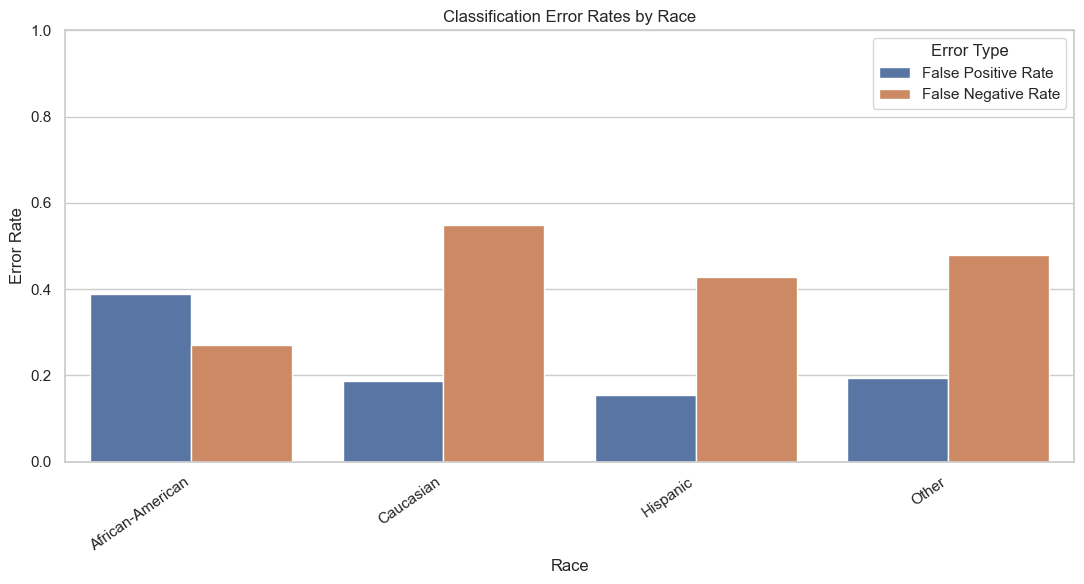

In [18]:
race_error_plot = race_metrics.melt(
    id_vars="Race",
    value_vars=["False Positive Rate", "False Negative Rate"],
    var_name="Error Type",
    value_name="Rate"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=race_error_plot,
    x="Race",
    y="Rate",
    hue="Error Type"
)

plt.title("Classification Error Rates by Race")
plt.xlabel("Race")
plt.ylabel("Error Rate")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "race_error_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

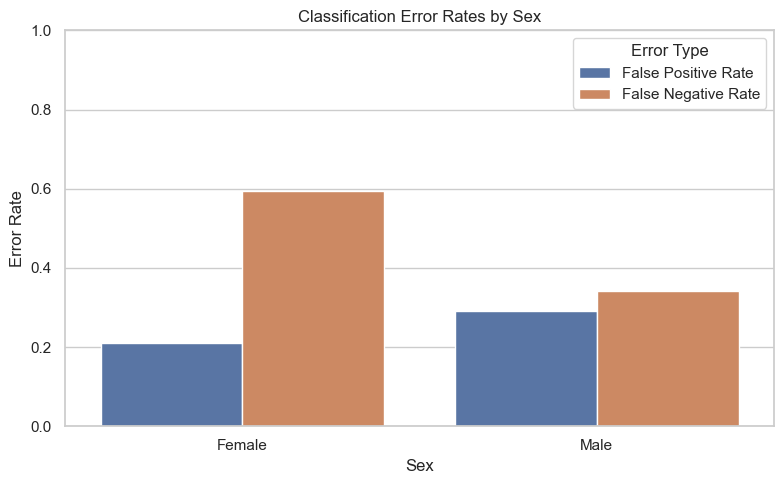

In [19]:
sex_error_plot = sex_metrics.melt(
    id_vars="Sex",
    value_vars=["False Positive Rate", "False Negative Rate"],
    var_name="Error Type",
    value_name="Rate"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=sex_error_plot,
    x="Sex",
    y="Rate",
    hue="Error Type"
)

plt.title("Classification Error Rates by Sex")
plt.xlabel("Sex")
plt.ylabel("Error Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "sex_error_rates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
# Exports for GitHub repository
validation_results_df.to_csv(
    OUTPUT_DIR / "validation_model_results.csv"
)

final_results_df.to_csv(
    OUTPUT_DIR / "final_test_results.csv"
)

coefficient_table.to_csv(
    OUTPUT_DIR / "logistic_regression_coefficients.csv",
    index=False
)

race_metrics.to_csv(
    OUTPUT_DIR / "fairness_metrics_by_race.csv",
    index=False
)

sex_metrics.to_csv(
    OUTPUT_DIR / "fairness_metrics_by_sex.csv",
    index=False
)

print("Saved figures to:", FIGURE_DIR.resolve())
print("Saved output tables to:", OUTPUT_DIR.resolve())

Saved figures to: C:\Users\tyboo\Documents\RecidivismAnalysis\images
Saved output tables to: C:\Users\tyboo\Documents\RecidivismAnalysis\outputs



## Conclusions and Limitations

### Model Performance

This project compared a Dummy Classifier baseline, Logistic Regression model, and Random Forest model using a validation split from the provided training dataset. Based on validation ROC-AUC, the selected model was Logistic Regression.

When evaluated once on the untouched held-out test dataset, the selected model achieved:

- Accuracy: 0.675
- Precision: 0.671
- Recall: 0.617
- F1-score: 0.643
- ROC-AUC: 0.726

### Interpretability

Logistic Regression was examined as an interpretable model using standardized coefficients. 

- Strongest positive association: priors_count, coefficient = 0.855
- Strongest negative association: age, coefficient = -0.501

These coefficients describe associations within the fitted model and should not be interpreted as causal effects.

### Fairness Evaluation

Race and sex were excluded from model training and used only for subgroup evaluation. The fairness analysis compared false positive and false negative rates across groups to identify whether model errors differed meaningfully across demographic categories. Subgroup results are reported only for groups with at least 30 observations in the held-out test dataset; smaller groups were excluded to avoid interpreting unstable error-rate estimates.

Among the racial groups with at least 30 test observations, the African-American subgroup had a higher false positive rate than the Caucasian subgroup (0.388 compared with 0.188), while the Caucasian subgroup had a higher false negative rate than the African-American subgroup (0.548 compared with 0.271). By sex, the female subgroup had a higher false negative rate than the male subgroup (0.594 compared with 0.342).

Differences in subgroup error rates are important because false positives and false negatives may create unequal consequences in a criminal justice context. These results should therefore be treated as a diagnostic warning rather than evidence that the model is appropriate for real-world decision-making.

### Limitations

- The COMPAS dataset reflects historical criminal justice outcomes and may contain structural or measurement bias.
- Excluding race and sex from model training does not guarantee fair predictions.
- Age remains a model predictor and should also be interpreted carefully as a sensitive attribute.
- Predictive performance alone is insufficient to justify use in a high-stakes setting.
- The analysis is educational and is not intended for real-world criminal justice decisions.

### Final Takeaway

This project demonstrates a reproducible workflow for exploratory analysis, leakage-free classification modeling, held-out evaluation, model interpretability, and subgroup fairness auditing in a sensitive application area. The project highlights the importance of evaluating not only whether a model predicts accurately, but also how its errors may differ across groups.
